In [1]:
!pip install numpy scikit-learn compress-fasttext xmltodict matplotlib

In [2]:
!pip install ruwordnet

In [ ]:
!ruwordnet download

downloading a ruwordnet model from https://github.com/avidale/python-ruwordnet/releases/download/0.0.4/ruwordnet-2021.db


In [3]:
from ruwordnet import RuWordNet
wn = RuWordNet()

In [4]:
# в какие синсеты входит слово "замок"? Иначе: какие значения "senses" имеет слово "замок"?
# два значения => два синсета, соответствующие этим значениям
for sense in wn.get_senses('замок'):
  print(sense.synset)

Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК")
Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")


In [5]:
# для первого синсета, в который входит слово "замок" получим его гиперонимы
wn.get_senses('замок')[0].synset.hypernyms

[Synset(id="113935-N", title="ДВОРЕЦ"),
 Synset(id="124420-N", title="КРЕПОСТЬ (ОБОРОНИТЕЛЬНОЕ СООРУЖЕНИЕ)")]

In [6]:
# то же самое для слова "спаржа"
wn.get_senses('спаржа')[0].synset.hypernyms

[Synset(id="348-N", title="ОВОЩИ"),
 Synset(id="4789-N", title="ТРАВЯНИСТОЕ РАСТЕНИЕ"),
 Synset(id="6878-N", title="ОВОЩНАЯ КУЛЬТУРА")]

In [7]:
wn.get_senses('авокадо') # значения слова "авокадо"

[Sense(id="144242-N-124560", name="АВОКАДО"),
 Sense(id="144305-N-124560", name="АВОКАДО"),
 Sense(id="153966-N-124560", name="АВОКАДО")]

In [8]:
# для первого значения слова "спаржа" получаем его синсет, затем находим его гиперонимы и берём первый из них
veg = wn.get_senses('спаржа')[0].synset.hypernyms[0]
veg

Synset(id="348-N", title="ОВОЩИ")

In [9]:
# в итоге получаем гипонимы овощей => согипонимы для слова "спаржа"
veg.hyponyms

[Synset(id="144194-N", title="ТЫКВА (ПЛОД)"),
 Synset(id="153883-N", title="ЗЕЛЕНЬ (ОВОЩИ)"),
 Synset(id="144191-N", title="ПОМИДОР (ПЛОД)"),
 Synset(id="144205-N", title="ПАТИССОН (ПЛОД)"),
 Synset(id="118660-N", title="ЗЕЛЕНЫЙ ГОРОШЕК"),
 Synset(id="144182-N", title="ЛУК (РАСТЕНИЕ)"),
 Synset(id="144207-N", title="СТРУЧКОВЫЙ ПЕРЕЦ (ПЛОД)"),
 Synset(id="144181-N", title="БАКЛАЖАН (ПЛОД)"),
 Synset(id="107993-N", title="АРТИШОК"),
 Synset(id="144216-N", title="КАБАЧОК (ПЛОД)"),
 Synset(id="144183-N", title="ЧЕСНОК"),
 Synset(id="108482-N", title="СПАРЖА"),
 Synset(id="144232-N", title="КОЧАН КАПУСТЫ"),
 Synset(id="148896-N", title="КОРНЕПЛОДНЫЕ ОВОЩИ"),
 Synset(id="144184-N", title="ОГУРЕЦ (ПЛОД)")]

## Другие типы отношений

Домент - атрибут

In [10]:
wn.get_senses('мяч')[0].synset.domains

[Synset(id="109383-N", title="ИГРА (РАЗВЛЕЧЕНИЕ)"),
 Synset(id="1622-N", title="СПОРТ")]

In [11]:
import random
for item in random.sample(wn['музыка'][0].synset.domain_items, 10):
  print(item)

Synset(id="143864-V", title="ПЕНИЕ КАРАОКЕ")
Synset(id="148378-V", title="РАЗЫГРАТЬСЯ (УПРАЖНЯТЬСЯ)")
Synset(id="150475-A", title="МУЗЫКАЛЬНОСТЬ (СПОСОБНОСТЬ)")
Synset(id="108904-A", title="БАС (ГОЛОС)")
Synset(id="1442-A", title="КОНСЕРВАТОРИЯ")
Synset(id="118657-V", title="НАПЕВАТЬ ПЕСНЮ")
Synset(id="9743-N", title="КЛАВЕСИН")
Synset(id="117900-A", title="МУЗЫКАЛЬНАЯ ВАРИАЦИЯ")
Synset(id="107996-A", title="СТРУННЫЙ МУЗЫКАЛЬНЫЙ ИНСТРУМЕНТ")
Synset(id="127633-N", title="ПОДПЕТЬ, ПОДТЯНУТЬ ПЕСНЮ")


In [12]:
# другие атрибуты домена СПОРТ (наравне с мячом)
wn.get_senses('мяч')[0].synset.domains[1].domain_items

[Synset(id="10014-A", title="ТЕННИСНЫЙ КОРТ"),
 Synset(id="10014-N", title="ТЕННИСНЫЙ КОРТ"),
 Synset(id="10040-A", title="ГАНДБОЛ"),
 Synset(id="10040-N", title="ГАНДБОЛ"),
 Synset(id="10244-A", title="АЛЬПИНИСТ"),
 Synset(id="10244-N", title="АЛЬПИНИСТ"),
 Synset(id="10267-N", title="ГОЛЬФ"),
 Synset(id="107172-N", title="СПОРТИВНАЯ ДИСТАНЦИЯ"),
 Synset(id="108790-N", title="КАНОЭ"),
 Synset(id="109299-N", title="СПОРТИВНАЯ БОРЬБА"),
 Synset(id="109300-N", title="КАРАТЭ"),
 Synset(id="109397-A", title="БЕЙСБОЛ"),
 Synset(id="109397-N", title="БЕЙСБОЛ"),
 Synset(id="109400-A", title="РЕГБИ"),
 Synset(id="109400-N", title="РЕГБИ"),
 Synset(id="109403-A", title="ХОККЕЙ НА ЛЬДУ"),
 Synset(id="109403-N", title="ХОККЕЙ НА ЛЬДУ"),
 Synset(id="109404-A", title="ШАШКИ"),
 Synset(id="109404-N", title="ШАШКИ"),
 Synset(id="109524-A", title="ГОРОДКИ"),
 Synset(id="109524-N", title="ГОРОДКИ"),
 Synset(id="109648-N", title="ДЖИУ-ДЖИТСУ"),
 Synset(id="109649-A", title="ДЗЮДО"),
 Synset(id="109649-N

Часть - целое (меронимы - холонимы)

In [13]:
wn.get_senses('автомобиль')[0].synset.meronyms # части автомобиля

[Synset(id="125151-N", title="БАМПЕР АВТОМОБИЛЯ"),
 Synset(id="126573-N", title="КУЗОВ АВТОМОБИЛЯ"),
 Synset(id="2653-N", title="АВТОМОБИЛЬНОЕ ОБОРУДОВАНИЕ"),
 Synset(id="108798-N", title="КАПОТ МАШИНЫ")]

In [14]:
wn.get_senses('страница')[0].synset.holonyms # частью чего является страница?

[Synset(id="3790-N", title="КНИГА (ИЗДАНИЕ)"),
 Synset(id="5820-N", title="ТЕТРАДЬ")]

Класс - экземпляр

In [15]:
# экземпляром какого класса является "москва-река"?
wn['москва-река'][0].synset.classes

[Synset(id="136791-N", title="РЕКИ РОССИЙСКОЙ ФЕДЕРАЦИИ")]

In [16]:
# экземпляры класса "областной центр"
wn['областной центр'][0].synset.instances

[Synset(id="100355-N", title="АСТРАХАНЬ"),
 Synset(id="101407-N", title="КОСТРОМА"),
 Synset(id="102587-N", title="САРАТОВ"),
 Synset(id="105766-N", title="ЮЖНО-САХАЛИНСК"),
 Synset(id="102937-N", title="ТЮМЕНЬ"),
 Synset(id="102849-N", title="ТВЕРЬ"),
 Synset(id="102325-N", title="ОРЕНБУРГ"),
 Synset(id="101352-N", title="КИРОВ (ВЯТКА)"),
 Synset(id="100628-N", title="ВОЛГОГРАД"),
 Synset(id="102104-N", title="МУРМАНСК"),
 Synset(id="101001-N", title="ИВАНОВО"),
 Synset(id="100244-N", title="БЛАГОВЕЩЕНСК"),
 Synset(id="103066-N", title="ЧЕЛЯБИНСК"),
 Synset(id="102903-N", title="ТОМСК"),
 Synset(id="102373-N", title="ПЕНЗА"),
 Synset(id="102220-N", title="НОВОСИБИРСК"),
 Synset(id="102521-N", title="РОСТОВ-НА-ДОНУ"),
 Synset(id="100438-N", title="БЕЛГОРОД"),
 Synset(id="102207-N", title="НОВГОРОД"),
 Synset(id="100484-N", title="БРЯНСК"),
 Synset(id="100650-N", title="ВОЛОГДА"),
 Synset(id="101142-N", title="КАЛУГА"),
 Synset(id="100328-N", title="АРХАНГЕЛЬСК"),
 Synset(id="103153-N",

Вот сколько у нас много областных центров!!

Предпосылки - выводы

In [17]:
wn['убить'][0].synset.premises

[]

Странно, а на гитхабе тут была непустая выдача...

In [18]:
wn['завоевать'][0].synset.conclusions

[Synset(id="106961-V", title="СОРЕВНОВАНИЕ, СОСТЯЗАНИЕ")]

Причины - следствия

In [19]:
wn['устать'][0].synset.causes

[Synset(id="114599-V", title="УТОМИТЬ")]

In [20]:
wn['утомить'][0].synset.effects

[Synset(id="117320-V", title="УТОМИТЬСЯ, УСТАТЬ")]

Частеречные синонимы

In [21]:
for ss in wn['убить'][0].synset.pos_synonyms: # частеречные синонимы первого синсета слова "убить" (перебираем их в цикле)
  senses = ss.senses # значения, составляющие данный синсет
  for s in senses:
    print(s)

Sense(id="4628-N-113272", name="УБИЙСТВО")
Sense(id="4628-N-122192", name="НАСИЛЬСТВЕННАЯ СМЕРТЬ")
Sense(id="4628-N-193508", name="МОКРОЕ ДЕЛО")
Sense(id="4628-N-193509", name="МОКРУХА")
Sense(id="4628-N-201792", name="СМЕРТОУБИЙСТВО")
Sense(id="4628-N-723414", name="ЧЕЛОВЕКОУБИЙСТВО")
Sense(id="4628-N-731703", name="УБИЙСТВО ЧЕЛОВЕКА")
Sense(id="4628-N-768279", name="ПРИЧИНЕНИЕ СМЕРТИ")


In [22]:
# то же самое, но короче (не до конца понимаю, как именно)
[s for ss in wn['убить'][0].synset.pos_synonyms for s in ss.senses]

[Sense(id="4628-N-113272", name="УБИЙСТВО"),
 Sense(id="4628-N-122192", name="НАСИЛЬСТВЕННАЯ СМЕРТЬ"),
 Sense(id="4628-N-193508", name="МОКРОЕ ДЕЛО"),
 Sense(id="4628-N-193509", name="МОКРУХА"),
 Sense(id="4628-N-201792", name="СМЕРТОУБИЙСТВО"),
 Sense(id="4628-N-723414", name="ЧЕЛОВЕКОУБИЙСТВО"),
 Sense(id="4628-N-731703", name="УБИЙСТВО ЧЕЛОВЕКА"),
 Sense(id="4628-N-768279", name="ПРИЧИНЕНИЕ СМЕРТИ")]

Антонимы

In [23]:
wn['быстрый'][0].synset.antonyms

[Synset(id="118957-A", title="МЕДЛЕННЫЙ, НЕБЫСТРЫЙ")]

Следующие отношения существуют между смыслами (senses), а не между синсетами (synsets)

Фразы и их составляющие

In [24]:
# в какие фразы входит слово "быстрый?"
wn['быстрый'][0].phrases

[Sense(id="102679-N-129996", name="РЕКА БЫСТРАЯ"),
 Sense(id="8930-N-117128", name="БЫСТРОЕ ПИТАНИЕ"),
 Sense(id="9241-N-118631", name="БЫСТРЫЕ ШАХМАТЫ")]

In [25]:
wn['послужной список'][0].words

[Sense(id="106989-N-153921", name="СПИСОК")]

Словообразование

In [26]:
wn['красный'][0].derivations

[Sense(id="109437-A-205240", name="КРАСНОВАТЫЙ"),
 Sense(id="109437-N-140855", name="КРАСНОТА"),
 Sense(id="110417-N-702073", name="ПОКРАСНЕНИЕ"),
 Sense(id="110417-V-140852", name="КРАСНЕТЬ"),
 Sense(id="110417-V-147981", name="ПОКРАСНЕТЬ"),
 Sense(id="110417-V-182793", name="ЗАКРАСНЕТЬ"),
 Sense(id="111004-V-140852", name="КРАСНЕТЬ"),
 Sense(id="111004-V-182793", name="ЗАКРАСНЕТЬ")]

### Предсказание гиперонимов

In [27]:
import numpy as np
import compress_fasttext
# библиотека для сжатия моделей fast_text
# github: https://github.com/avidale/compress-fasttext?tab=readme-ov-file
# статья на Хабре (на русском!!): https://habr.com/en/articles/489474/

from collections import Counter
from sklearn.neighbors import KDTree # библиотека для деления k-мерного пространства на отдельные фрагменты

import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
# загружаем fasttext модель, которая уже была сжата заранее
ft = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)

In [29]:
# функция для векторизации текста
def vectorize(text):
    vec = np.mean([ft[word] for word in text.lower().split() if len(word) >= 3], axis=0) # вектор текста = среднее векторов слов этого текста (для слов длиннее трёх букв)
    vec /= sum(vec**2) ** 0.5 # возводим вектор vec в квадрат, складываем все чиселки этого вектора, извлекаем из этого квадратный корень и на всю эту кракозябру делим исходный вектор vec
    return vec # в итоге vec - это какое-то одно число

def distance2vote(d, a=3, b=5): # преобразование расстояние в голосование?? Не очень понятно конечно
    sim = np.maximum(0, 1 - d**2/2)
    return np.exp(-d**a) * sim **b
# то есть примерно вот что: измеряем семантическую близость векторов на основе их расстоянии в линейном пространстве

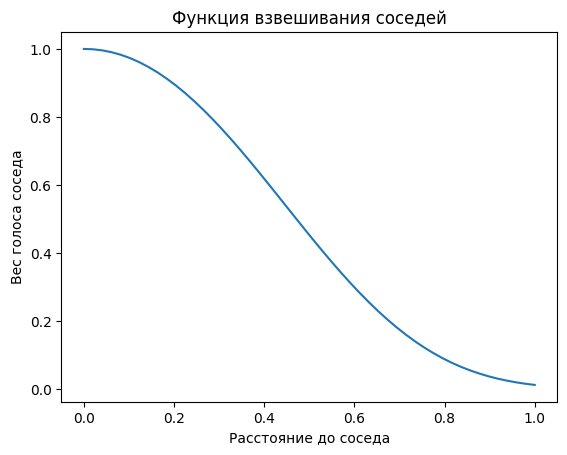

In [30]:
x = np.linspace(0, 1) # возвращает равномерно распределённые значения в пределах указанного интервала (здесь: 50 чисел, лежащих между 0 и 1, на одинаковом расстоянии друг от друга)
plt.plot(x, distance2vote(x)) # по горизонтали - расстояние между векторами, по вертикали - оценка семантической близости
plt.xlabel('Расстояние до соседа')
plt.ylabel('Вес голоса соседа')
plt.title('Функция взвешивания соседей');

In [31]:
from tqdm.auto import tqdm, trange

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
words, vectors, synset_ids = [], [], []
for synset in tqdm(wn.synsets): # в цикле перебираем все синсеты тезауруса
    if synset.part_of_speech != 'V': # если не глагол - пропускаем
        continue
    for sense in synset.senses: # для смыслов данного синсета
        words.append(sense.name) # добавляем слово
        vectors.append(vectorize(sense.name)) # добавляем вектор этого слова
        synset_ids.append(synset.id) # добавляем id синсета
vectors = np.stack(vectors) # объединяем вектора, получаем трёхмерное пространство
#tree = KDTree(vectors) # на основе этого пространства строим дерево

100%|██████████| 59905/59905 [07:30<00:00, 132.95it/s]   


Вспомогательный пример для np.stack

In [33]:
tree = KDTree(vectors) # на основе этого пространства строим дерево

In [34]:
# np.stack - объединяет последовательность массивов по новой оси
# axis=0 - объединяем массивы по первой оси
# получается, что мы складываем все массивы "друг на друга", поэтому длина новой оси = 10 (исходно у нас было 10 массивов)
arrays = [np.random.randn(3, 4) for _ in range(10)] # 10 массивов размерности 3*4 (3 строки, 4 столбца)
arrays[0]
np.stack(arrays, axis=0).shape

(10, 3, 4)

In [35]:
tree = KDTree(vectors) # на основе этого пространства строим дерево

In [36]:
votes = Counter() # словарь вида значение: сколько раз значение встретилось
dists, ids = tree.query(vectorize('кудахтать').reshape(1, -1), k=100) # для слова "кудахтать" запрашиваем кусочек пространства из дерева?
for idx, distance in zip(ids[0], dists[0]):
    for hyper in wn[synset_ids[idx]].hypernyms: # получаем синсет по id и находим его гиперонимы
        votes[hyper.id] += distance2vote(distance) # для id каждого гиперонима: прибавляем значение семантической близости, предсказанное функцией distance2vote
    print(words[idx], [t.title for t in wn[synset_ids[idx]].hypernyms]) # слово, гипероним

КУДАХТАТЬ ['ИЗДАТЬ ЗВУК']
ПАХТАТЬ ['СБИТЬ В ПЛОТНУЮ МАССУ']
РАСКУДАХТАТЬСЯ ['ИЗДАТЬ ЗВУК']
КЛОХТАТЬ ['ИЗДАТЬ ЗВУК']
СБЕГАТЬ ТУДА И ОБРАТНО ['СХОДИТЬ ТУДА И ОБРАТНО']
БАРАХТАТЬСЯ ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ', 'ПЛЕСКАТЬСЯ В ВОДЕ']
СНОВАТЬ ТУДА-СЮДА ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
СХОДИТЬ ТУДА И ОБРАТНО ['ИДТИ НОГАМИ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
ПОДЛАТАТЬ ['ЗАШИТЬ ДЫРУ', 'НАШИТЬ СВЕРХУ']
ЗАНЫРНУТЬ ['ПОГРУЗИТЬСЯ В ЖИДКОСТЬ']
СНОВАТЬ ТУДА И ОБРАТНО ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
ПОПРЯТАТЬ ['ОБЕРЕГАТЬ, ЗАЩИЩАТЬ']
ПОПРЯТАТЬ ['НАКРЫТЬ, ПОКРЫТЬ СВЕРХУ']
СПЛАВАТЬ ТУДА И ОБРАТНО ['ПЛЫТЬ (ПЕРЕДВИГАТЬСЯ ПО ВОДЕ)', 'ПЛЫТЬ НА СУДНЕ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
РЫПАТЬСЯ ['ПЫТАТЬСЯ, СТАРАТЬСЯ', 'ХОТЕТЬ, ИМЕТЬ ЖЕЛАНИЕ']
СБЕГАТЬ И ВЕРНУТЬСЯ ['СХОДИТЬ ТУДА И ОБРАТНО']
БУРЧАТЬ ['БОРМОТАТЬ']
БУРЧАТЬ ['ИЗДАТЬ ЗВУК']
ПЕРЕБАРЫВАТЬ ['ПРЕВЗОЙТИ']
ПЕРЕБАРЫВАТЬ ['ПРЕОДОЛЕТЬ']
БРАТЬСЯ ['ПОЯВИТЬСЯ, ВОЗНИКНУТЬ, НАЧАТЬСЯ']
БРАТЬСЯ ['НАЧАТЬ, ПРИСТУПИТЬ, ПРИНЯТЬСЯ', 'ОБЯЗАТЬСЯ']
БРАТЬСЯ ['БРАТЬ РУКОЙ, ЗУБАМИ, ОРУДИЕМ']
БРАТЬСЯ ['П

In [37]:
# напечатаем 10 наиболее семантически близких к данному слову гиперонимов
for sid, score in votes.most_common(10):
    print(score,  wn[sid].title)

1.693910435463562 ИЗДАТЬ ЗВУК
0.4132547441687813 ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ
0.3097076148668363 СБИТЬ В ПЛОТНУЮ МАССУ
0.25169095401266095 СПУСТИТЬСЯ ВНИЗ
0.22120903181668677 СХОДИТЬ ТУДА И ОБРАТНО
0.20195221302283534 ОБЕРНУТЬСЯ ТУДА И ОБРАТНО
0.1896130809969685 ЗАШИТЬ ДЫРУ
0.1896130809969685 НАШИТЬ СВЕРХУ
0.18951210591007633 ИДТИ НОГАМИ
0.1778837765054719 КАЧАТЬ (КОЛЕБАТЬ)


### Найди лишнее

Какое из слов ДИВАН, ШКАФ, ЛАМПА, СТОЛ лишнее?

In [38]:
import math


def get_all_hypernyms(wn, word, max_level=100):
    """ Return dict of all hypernyms of a word and their distances """
    """Возвращает все гиперонимы слова word и их расстояния"""
    front = [sense.synset for sense in wn.get_senses(word)] # список синсетов всех значений слова "word"
    levels = {}
    for level in range(max_level):
        if not front: # если список синсетов пуст - прерываем, иначе - продолжаем
            break
        new_front = []
        for synset in front:
            if synset.id not in levels:
                levels[synset.id] = level # добавляем в словарь пару id синсета: уровень (непонятно, что за уровень, но у каждого синсета он будет самый ранний встреченный)
                new_front.extend(synset.hypernyms) # добавляем в список new_front гиперонимы
        front = new_front
    return levels

def get_closest_common(levels1, levels2): # на вход - гиперонимы + расстояния для Слова 1 и гиперонимы + расстояния для Слова 2
    """ Find the closest common hypernym and sum of distances to it"""
    """Возвращает самый близкий гипероним и суммирует расстояния до него"""
    result = None
    result_distance = math.inf # положительная бесконечность, тип - float
    for id, distance in levels1.items():
        if id in levels2:
            total = distance + levels2[id]
            if total < result_distance: # чем меньше значение distance - тем семантически ближе данный гипероним
                result_distance = total # обнавляем значение расстояния
                result = id # и значение id самого подходящего синсета-гиперонима
    return result, result_distance

In [39]:
# получим таблицу с расстояниями между соотв. словами? (вроде бы...)
words = ['ДИВАН', 'ШКАФ', 'ЛАМПА', 'СТОЛ']
print('\t\t', '\t'.join(words))
for w1 in words:
    print(w1, end='\t')
    for w2 in words:
        n, d = get_closest_common(get_all_hypernyms(wn, w1), get_all_hypernyms(wn, w2))
        print(d, end='\t\t')
    print()

		 ДИВАН	ШКАФ	ЛАМПА	СТОЛ
ДИВАН	0		3		10		3		
ШКАФ	3		0		5		2		
ЛАМПА	10		5		0		7		
СТОЛ	3		2		7		0		


Наверное, где самые большие расстояния до блиайшего общего гиперонима, то и лишнее (здесь - лампа)

In [40]:
# видимо, наиболее близкий общий гипероним! id синсета и название этого синсета
name, distance = get_closest_common(get_all_hypernyms(wn, 'лампа'), get_all_hypernyms(wn, 'шкаф'))
print(distance, name, wn[name].title)

5 106555-N ТЕХНИЧЕСКОЕ УСТРОЙСТВО


In [41]:
# гиперонимы слова "лампа": id гиперонима, расстояние до слова "лампа", сам синсет гиперонима
for k, v in get_all_hypernyms(wn, 'лампа').items():
    print(k, v, wn[k])

128561-N 0 Synset(id="128561-N", title="ОСВЕТИТЕЛЬНЫЙ ПРИБОР")
8785-N 0 Synset(id="8785-N", title="ЭЛЕКТРИЧЕСКАЯ ЛАМПА")
107646-N 1 Synset(id="107646-N", title="ИСТОЧНИК ОСВЕЩЕНИЯ")
4222-N 1 Synset(id="4222-N", title="СВЕТОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106488-N 2 Synset(id="106488-N", title="ИСХОДНЫЙ ПУНКТ")
2070-N 2 Synset(id="2070-N", title="ЭЛЕКТРОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106613-N 3 Synset(id="106613-N", title="РОЛЬ, ПОЛОЖЕНИЕ, МЕСТО")
149201-N 3 Synset(id="149201-N", title="ИНЖЕНЕРНОЕ ОБОРУДОВАНИЕ")
106555-N 4 Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО")
1320-N 4 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")
106553-N 5 Synset(id="106553-N", title="ПРИСПОСОБЛЕНИЕ (ПРЕДМЕТ)")
106554-N 6 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
147133-N 7 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
147134-N 8 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
153782-N 9 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")


### Word Sense Disambiguation (WSD)

зАмок или замОк?

Примитивный алгоритм: для каждого значения находим синонимы и проверяем, какие ближе по fasttext-эмбеддингу к словам контекста.

Для верности, стоило бы кроме синонимов взять ещё и ко-гипонимы.

In [42]:
!pip install razdel

In [43]:
import razdel # библиотека для токенизации

In [44]:
context = '''Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок
― бороздку, называемую "зигом", которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'''
word = 'замок'

In [45]:
def disambiguate(word, context):
    candidates = [s.synset for s in wn[word]] # кандидаты для разрешения семантической неоднозначности - значения целевого слова word
    text_vector = vectorize(' '.join(t.text for t in razdel.tokenize(context) if t.text != word)) # векторизуем текст; перед этим его токенизируем с помощью razdel; целевое слово не учитываем!
    candidate_vectors = [ # получим вектора значений-кандидатов
        vectorize(' '.join(w for s in c.senses for w in s.name.lower().split() if name != word))
        for c in candidates # перебираем кандидатов
    ]
    # запуталась в циклах, но по сути: для каждого кандидата (это синсет) берём его senses, достаём их названия, соединяем через пробел и всё это векторизуем, при этом целевое слово опять не учитываем
    scores = [np.dot(text_vector, v) for v in candidate_vectors] # оценка = скалярное произведение вектора-текста и вектора-кандидата
    # чем выше эта оценка, тем вероятнее неоднозначное слово употреблено в данном значении

    return dict(zip(scores, candidates))

In [46]:
disambiguate(word, context)

{0.4421322748905842: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.55319632362594: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}

Видно, что замОк для запирания - более вероятен

Рассмотрим другой контекст

In [47]:
context = '''Издали видны королевский замок Вавель и кафедральный собор Святых Вацлава и Станислава
― настоящие шедевры зодчества.'''
disambiguate(word, context)

{0.6623339070392336: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.5569728387813148: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}

В данном случае более вероятен зАмок

### ДЗ

**Задание**: повторить эксперимент Д. Дале - разрешить неоднозначность с использованием ruwordnet и fasttext
*  Орган и оргАн
*  Дом
*  Площадь
*  Вид
*  Глава

**Орган vs оргАн**

In [48]:
word = 'орган'
context1 = 'Человеческое тело — физическая структура человека, человеческий организм. Тело человека образовано клетками различных типов, \
характерным образом организующихся в ткани, которые формируют органы, заполняют пространство между ними или покрывают снаружи.' # Орган
context2 = 'Орган – самый большой духовой клавишный музыкальный инструмент. Звук извлекается при помощи труб (металлических, деревянных, с язычками и без).\
 Звукоизвлекающие элементы имеют разный тембр, а нагнетание воздуха выполняется мехами. Играют на инструменте с помощью клавиатур для рук (мануалов) и педальной клавиатуры.' # оргАн

In [49]:
scores1 = disambiguate(word, context1)
max_score = max(scores1.keys())
print(f'Значение в данном контексте: {scores1[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="106580-N", title="ОРГАН ЖИВОГО ОРГАНИЗМА") - 0.7115057994522254


In [50]:
scores2 = disambiguate(word, context2)
max_score = max(scores2.keys())
print(f'Значение в данном контексте: {scores2[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="8508-N", title="ОРГАН (МУЗЫКАЛЬНЫЙ ИНСТРУМЕНТ)") - 0.6555466661929419


**дом**

In [51]:
# посмотрим на синсеты слова "дом"
for s in wn.get_senses('дом'):
  print(s.synset)

Synset(id="130946-N", title="ДОМ (СВОЕ ЖИЛЬЕ)")
Synset(id="2526-N", title="ЗДАНИЕ")


In [52]:
word = 'дом'
context1 = 'существует множество натуральных моющих средств, они просты в использовании, и порою часто их можно найти у себя в доме.' # дом - своё жильё
context2 = 'А это пшеница, Которая в тёмном чулане хранится В доме, Который построил Джек.' # дом - здание

In [53]:
scores1 = disambiguate(word, context1)
max_score = max(scores1.keys())
print(f'Значение в данном контексте: {scores1[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="130946-N", title="ДОМ (СВОЕ ЖИЛЬЕ)") - 0.6906130313560345


In [54]:
scores2 = disambiguate(word, context2)
max_score = max(scores2.keys())
print(f'Значение в данном контексте: {scores2[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="130946-N", title="ДОМ (СВОЕ ЖИЛЬЕ)") - 0.6879199362547544


Не сработало:)

**площадь**

In [55]:
for s in wn.get_senses('площадь'):
  print(s.synset)

Synset(id="107315-N", title="ПЛОЩАДЬ (ПАРАМЕТР)")
Synset(id="114034-N", title="ПЛОЩАДЬ В ГОРОДЕ, СЕЛЕ")


In [56]:
word = 'площадь'
context1 = 'Отношение площади квадрата, построенного на ординате, к площади прямоугольника,\
 построенного на двух абсциссах, одинаково для всех точек Р, лежащих на эллипсе.' # площадь - параметр
context2 = 'Тогда, в один из летних дней 1989 года, горняки шахты города Междуреченска, выйдя после смены из лавы\
 и не найдя в душевых ни куска хозяйственного мыла, все как были — в робе, касках с фонарями-коногонками — приехали на автобусах\
  к областной администрации и весь жаркий июльский день просидели перед ней на площади.' # площадь в городе, селе

In [57]:
scores1 = disambiguate(word, context1)
max_score = max(scores1.keys())
print(f'Значение в данном контексте: {scores1[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="107315-N", title="ПЛОЩАДЬ (ПАРАМЕТР)") - 0.6197670327430999


In [58]:
scores2 = disambiguate(word, context2)
max_score = max(scores2.keys())
print(f'Значение в данном контексте: {scores2[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="114034-N", title="ПЛОЩАДЬ В ГОРОДЕ, СЕЛЕ") - 0.5315811403030641


**вид**

In [59]:
for s in wn.get_senses('вид'):
  print(s.synset)

Synset(id="127597-N", title="БИОЛОГИЧЕСКИЙ ВИД")
Synset(id="112006-N", title="ВИД ГЛАГОЛА")
Synset(id="107545-N", title="ВНЕШНИЙ ОБЛИК")
Synset(id="120138-N", title="ТИП, ВИД, КЛАСС")
Synset(id="123619-N", title="ВИД ОКРУЖАЮЩЕЙ МЕСТНОСТИ")


In [60]:
# возьмём два значения: биологический вид и вид глагола
word = 'вид'
context1 = 'В 1979 г. в рамках международной программы был создан журавлиный питомник, в котором кроме стерха содержатся и остальные 6 видов журавлей фауны России.' # вид животных
context2 = 'Исходя из вполне законного рассуждения о том, что агентивные глаголы обозначают контролируемые действия, а в превентивных конструкциях\
 обозначаются неконтролируемые, неагентивные ситуации, Т. В. Булыгина высказала предположение, что " употребление формы совершенного вида от агентивных глаголов\
  невозможно даже по отношению к конкретному одноактному действию "' # вид глагола

In [61]:
scores1 = disambiguate(word, context1)
max_score = max(scores1.keys())
print(f'Значение в данном контексте: {scores1[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="120138-N", title="ТИП, ВИД, КЛАСС") - 0.6647477911087774


In [62]:
scores2 = disambiguate(word, context2)
max_score = max(scores2.keys())
print(f'Значение в данном контексте: {scores2[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="120138-N", title="ТИП, ВИД, КЛАСС") - 0.6333057231322781


Вообще не сработало

**глава**

In [63]:
for s in wn.get_senses('глава'):
  print(s.synset)

Synset(id="130563-N", title="КУПОЛ ЦЕРКВИ")
Synset(id="106606-N", title="РУКОВОДИТЕЛЬ")
Synset(id="107734-N", title="ГОЛОВА ЧЕЛОВЕКА")
Synset(id="114668-N", title="ГЛАВА ТЕКСТА")


Возьмём два значения: глава текста и руководитель

In [64]:
word = 'глава'
context1 = 'В заключение первой главы ученый познакомил читателей с историческими типами культурного ландшафта Кольского Севера, объединив их в три большие группы:\
 неурбанизированные, урбанизированные и переходные.' # глава текста
context2 = 'Тем более что указом президента с 1 июля (при закрытых дверях!) в разы повышена зарплата не только главы государства, но и его администрации,\
 полпредов в округах, премьера, министров, парламентариев обеих палат.' # руководитель

In [65]:
scores1 = disambiguate(word, context1)
max_score = max(scores1.keys())
print(f'Значение в данном контексте: {scores1[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="106606-N", title="РУКОВОДИТЕЛЬ") - 0.6870109427678261


Не сработало:(

In [66]:
disambiguate(word, context1)

{0.5873201874191533: Synset(id="130563-N", title="КУПОЛ ЦЕРКВИ"),
 0.6870109427678261: Synset(id="106606-N", title="РУКОВОДИТЕЛЬ"),
 0.6399090906239506: Synset(id="107734-N", title="ГОЛОВА ЧЕЛОВЕКА"),
 0.6407101589665392: Synset(id="114668-N", title="ГЛАВА ТЕКСТА")}

In [67]:
scores2 = disambiguate(word, context2)
max_score = max(scores2.keys())
print(f'Значение в данном контексте: {scores2[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="106606-N", title="РУКОВОДИТЕЛЬ") - 0.7209412652071715
